# Question 2 — Physical Size of Earrings

| Parameter | Symbol | Value |
|-----------|--------|-------|
| Focal length | $f$ | 8 mm |
| Pixel size | $p$ | 2.2 μm × 2.2 μm |
| Object distance (lens → earring plane) | $u$ | 720 mm |


Image size (W x H): 1024 x 1024 pixels


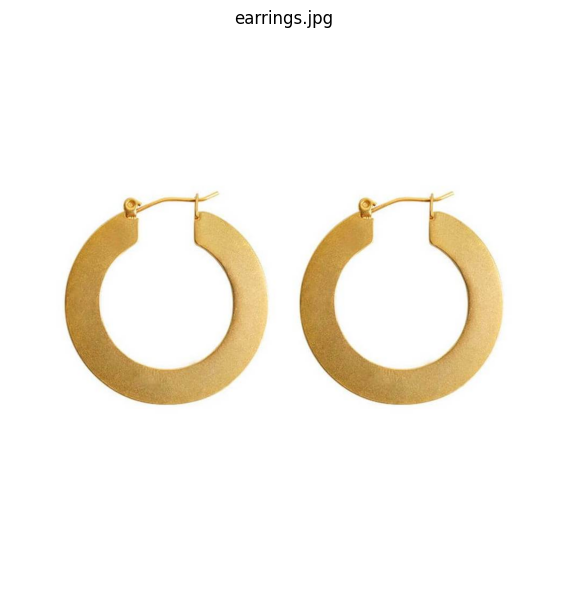

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

img     = cv.imread('../data/earrings.jpg')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
print('Image size (W x H):', img.shape[1], 'x', img.shape[0], 'pixels')
plt.figure(figsize=(8,6)); plt.imshow(img_rgb); plt.axis('off')
plt.title('earrings.jpg'); plt.tight_layout(); plt.show()


## Step 1 — Camera Geometry

Thin lens equation: $\frac{1}{f} = \frac{1}{u} + \frac{1}{v}$

Scale: $\text{mm/px} = p \cdot (u-f)/f$


In [2]:
f = 8.0;  p = 2.2e-3;  u = 720.0
v         = (f * u) / (u - f)
m         = v / u
mm_per_px = p / m
print('Image distance  v  =', round(v,5), 'mm')
print('Magnification   m  =', round(m,6))
print('Scale    mm/pixel  =', round(mm_per_px,5), ' (', round(mm_per_px*1000,3), 'um/px)')


Image distance  v  = 8.08989 mm
Magnification   m  = 0.011236
Scale    mm/pixel  = 0.1958  ( 195.8 um/px)


## Step 2 — Segment and Measure

HSV threshold on gold colour → `RETR_CCOMP` contours → `minEnclosingCircle`
for outer rim (parent contour) and inner hole (child contour).


In [3]:
hsv  = cv.cvtColor(img, cv.COLOR_BGR2HSV)
mask = cv.inRange(hsv, (10, 40, 80), (40, 255, 255))
kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (7, 7))
mask   = cv.morphologyEx(mask, cv.MORPH_CLOSE, kernel, iterations=2)
mask   = cv.morphologyEx(mask, cv.MORPH_OPEN,  kernel, iterations=1)

contours, hier = cv.findContours(mask, cv.RETR_CCOMP, cv.CHAIN_APPROX_SIMPLE)
hier = hier[0]

outer_c = sorted([contours[i] for i in range(len(contours))
                  if hier[i][3]==-1 and cv.contourArea(contours[i])>5000],
                 key=cv.contourArea, reverse=True)[:2]
inner_c = sorted([contours[i] for i in range(len(contours))
                  if hier[i][3]!=-1 and cv.contourArea(contours[i])>2000],
                 key=cv.contourArea, reverse=True)[:2]

def fit(c):
    (cx, cy), r = cv.minEnclosingCircle(c)
    return int(cx), int(cy), int(r)

outers = sorted([fit(c) for c in outer_c], key=lambda c: c[0])
inners = sorted([fit(c) for c in inner_c], key=lambda c: c[0])

print('Outer contours found:', len(outers))
print('Inner contours found:', len(inners))
for cx,cy,r in outers: print('  outer centre=(%d,%d) r=%dpx d=%dpx' % (cx,cy,r,2*r))
for cx,cy,r in inners: print('  inner centre=(%d,%d) r=%dpx d=%dpx' % (cx,cy,r,2*r))


Outer contours found: 2
Inner contours found: 2
  outer centre=(299,489) r=209px d=418px
  outer centre=(737,490) r=209px d=418px
  inner centre=(297,470) r=158px d=316px
  inner centre=(737,471) r=158px d=316px


## Step 3 — Real-World Sizes

$W_{\text{real}} = w_{\text{px}} \times \text{mm/px}$


In [4]:
px2mm = lambda px: px * mm_per_px

print('=== Earring Physical Sizes ===')
print('Scale: %.5f mm/pixel' % mm_per_px)
for i, ((ocx,ocy,or_),(icx,icy,ir_)) in enumerate(zip(outers, inners)):
    print('Earring %d:' % (i+1))
    print('  Outer diameter : %4d px  =>  %.2f mm' % (2*or_, px2mm(2*or_)))
    print('  Inner diameter : %4d px  =>  %.2f mm' % (2*ir_, px2mm(2*ir_)))
    print('  Band width     : %4d px  =>  %.2f mm' % (or_-ir_, px2mm(or_-ir_)))


=== Earring Physical Sizes ===
Scale: 0.19580 mm/pixel
Earring 1:
  Outer diameter :  418 px  =>  81.84 mm
  Inner diameter :  316 px  =>  61.87 mm
  Band width     :   51 px  =>  9.99 mm
Earring 2:
  Outer diameter :  418 px  =>  81.84 mm
  Inner diameter :  316 px  =>  61.87 mm
  Band width     :   51 px  =>  9.99 mm


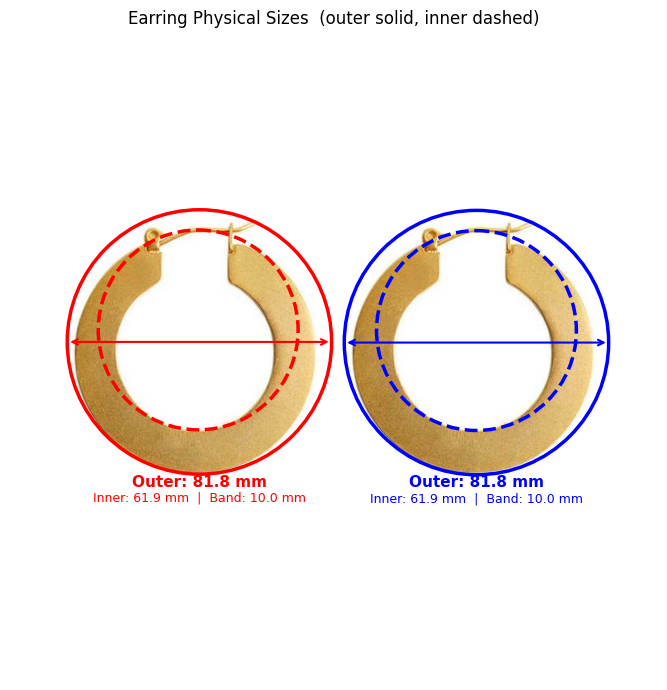

In [5]:
colors_e = ['red', 'blue']
fig, ax = plt.subplots(figsize=(10, 7))
ax.imshow(img_rgb)
for i, ((ocx,ocy,or_),(icx,icy,ir_)) in enumerate(zip(outers, inners)):
    col = colors_e[i]
    ax.add_patch(plt.Circle((ocx,ocy), or_, color=col, fill=False, linewidth=2.5))
    ax.add_patch(plt.Circle((icx,icy), ir_, color=col, fill=False, linewidth=2.5, linestyle='--'))
    ax.annotate('', xy=(ocx+or_, ocy), xytext=(ocx-or_, ocy),
                arrowprops=dict(arrowstyle='<->', color=col, lw=1.5))
    ax.text(ocx, ocy+or_+20, 'Outer: %.1f mm' % px2mm(2*or_),
            color=col, ha='center', fontsize=11, fontweight='bold')
    ax.text(ocx, ocy+or_+44, 'Inner: %.1f mm  |  Band: %.1f mm' % (px2mm(2*ir_), px2mm(or_-ir_)),
            color=col, ha='center', fontsize=9)
ax.set_title('Earring Physical Sizes  (outer solid, inner dashed)')
ax.axis('off')
plt.tight_layout()
plt.savefig('../output/p2_earring_sizes.png', dpi=150)
plt.show()
